In [1]:
import numpy as np
import copy

In [ ]:
# Seeds for reproducibility
data_seed = 42
init_seed = 0
dropout_seed = 123
rng = np.random.default_rng(data_seed)
rng_init = np.random.default_rng(init_seed)
rng_dropout = np.random.default_rng(dropout_seed)

In [3]:
# =========================
# 1. DATA GENERATION
# =========================
def generate_synthetic_data(n_samples=10, noise_scale=2.0, seed=42):
    rng = np.random.default_rng(seed)

    X1 = rng.integers(1, 10, size=n_samples).astype(float)
    X2 = rng.integers(1, 10, size=n_samples).astype(float)

    X3 = rng.integers(1, 10, size=n_samples).astype(float)
    X4 = rng.integers(1, 10, size=n_samples).astype(float)
    X5 = rng.integers(1, 10, size=n_samples).astype(float)

    noise = rng.normal(0, noise_scale, size=n_samples)
    y = 13 * X1 + 17 * X2 + noise

    X = np.column_stack([X1, X2, X3, X4, X5])
    return X, y

In [4]:
# =========================
# 2. GLOBAL CONFIG
# =========================
n_samples = 10
noise_scale = 2.0
keep_prob = 0.8
layer_dims = [4, 2, 1]
L = 3

In [5]:
# =========================
# 3. DATA PREP
# =========================
X, y = generate_synthetic_data(n_samples, noise_scale, data_seed)

X_train, X_test = X[:6], X[6:]
y_train, y_test = y[:6], y[6:]

X_train, X_test = X_train.T, X_test.T
y_train, y_test = y_train.reshape(1, -1), y_test.reshape(1, -1)

In [6]:
print(X_train, y_train, X_test, y_test)

[[1. 7. 6. 4. 4. 8.]
 [5. 9. 7. 7. 7. 8.]
 [5. 4. 2. 9. 8. 6.]
 [5. 3. 1. 5. 8. 1.]
 [2. 7. 7. 4. 1. 9.]] [[ 97.2957329  245.06461837 197.73088813 171.82546522 171.86164201
  244.2832952 ]] [[1. 7. 2. 1.]
 [5. 2. 8. 5.]
 [4. 8. 5. 4.]
 [8. 8. 3. 6.]
 [5. 9. 7. 8.]] [[ 97.18716997 123.97551454 160.37245454  99.23195885]]


In [7]:
# =========================
# 4. PARAM INIT
# =========================
def init_params(layer_dims, X_train, rng_init):
    """
    Initializes weights and biases using He initialization.

    Args:
        layer_dims: list of layer sizes, e.g. [4, 2, 1]
        X_train: training data (used to infer input size)
        rng_init: random number generator for initialization

    Returns:
        params: dictionary containing weights and biases
    """
    params = {}
    L = len(layer_dims)

    for l in range(1, L + 1):
        n_in = X_train.shape[0] if l == 1 else layer_dims[l - 2]
        n_out = layer_dims[l - 1]

        params[f"W{l}"] = rng_init.standard_normal((n_out, n_in)) * np.sqrt(2 / n_in)
        params[f"b{l}"] = np.zeros((n_out, 1))
    return params

In [8]:
params = init_params(layer_dims, X_train, rng_init)

for k, v in params.items():
    print(f"{k}: {v.shape}")

W1: (4, 5)
b1: (4, 1)
W2: (2, 4)
b2: (2, 1)
W3: (1, 2)
b3: (1, 1)


In [9]:
print(params)

{'W1': array([[ 0.07951877, -0.08355045,  0.40503885,  0.06634466, -0.33878706],
       [ 0.22869279,  0.82472204,  0.59898659, -0.44508124, -0.80032281],
       [-0.39419338,  0.02613684, -1.47047858, -0.138376  , -0.78798327],
       [-0.46312654, -0.3442196 , -0.20004578,  0.26033801,  0.65934335]]), 'b1': array([[0.],
       [0.],
       [0.],
       [0.]]), 'W2': array([[-0.09088773,  0.96623559, -0.47036366,  0.24855515],
       [ 0.63884989,  0.06647673, -0.52573336, -0.65175826]]), 'b2': array([[0.],
       [0.]]), 'W3': array([[-0.45772583,  0.22019512]]), 'b3': array([[0.]])}


In [ ]:
params_init = copy.deepcopy(params)

In [11]:
def forward(X, params, keep_prob=1.0, rng_dropout=None, train=True):
    cache = {"A0": X, "masks": {}}
    A = X

    for l in range(1, L + 1):
        W = params[f"W{l}"]
        b = params[f"b{l}"]
        Z = W @ A + b
        cache[f"Z{l}"] = Z
        # print(f"l = {l}, L = {L}")

        if l < L:
            A_relu = np.maximum(0, Z)  # ReLU
            cache[f"A{l}_relu"] = A_relu

            if train and keep_prob < 1.0:
                mask = rng_dropout.random(A_relu.shape) < keep_prob
                A = A_relu * mask / keep_prob
                cache["masks"][l] = mask
            else:
                A = A_relu
            cache[f"A{l}"] = A  # post-dropout
    return cache

In [12]:
cache = forward(X_train, params, keep_prob=0.8, rng_dropout=rng_dropout, train=True)
for k, v in cache.items():
    if k != "masks":
        print(f"{k}: {v.shape}")

A0: (5, 6)
Z1: (4, 6)
A1_relu: (4, 6)
A1: (4, 6)
Z2: (2, 6)
A2_relu: (2, 6)
A2: (2, 6)
Z3: (1, 6)


In [13]:
print("A1_relu:\n", cache["A1_relu"].round(3))
print("\nMask:\n", cache["masks"][1].astype(int))
print("\nA1 (post-dropout):\n", cache["A1"].round(3))

A1_relu:
 [[1.341 0.    0.    2.355 3.166 0.   ]
 [3.521 4.482 2.296 6.652 7.119 4.373]
 [0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.   ]]

Mask:
 [[1 1 1 1 1 0]
 [0 1 0 0 1 1]
 [0 1 1 1 0 1]
 [1 1 1 1 1 1]]

A1 (post-dropout):
 [[1.676 0.    0.    2.944 3.957 0.   ]
 [0.    5.602 0.    0.    8.898 5.467]
 [0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.   ]]


In [14]:
print("A2_relu:\n", cache["A2_relu"].round(3))
print("\nMask:\n", cache["masks"][2].astype(int))
print("\nA2 (post-dropout):\n", cache["A2"].round(3))

A2_relu:
 [[0.    5.413 0.    0.    8.238 5.282]
 [1.071 0.372 0.    1.881 3.119 0.363]]

Mask:
 [[1 1 1 1 0 1]
 [0 0 1 0 1 1]]

A2 (post-dropout):
 [[0.    6.766 0.    0.    0.    6.602]
 [0.    0.    0.    0.    3.899 0.454]]


In [15]:
print("Z3:\n", cache["Z3"].round(3))

Z3:
 [[ 0.    -3.097  0.     0.     0.859 -2.922]]


In [16]:
def compute_loss(cache, y):
    m = y.shape[1]
    Z3 = cache["Z3"]
    loss = np.sum((Z3 - y) ** 2) / (2 * m)
    return loss

In [17]:
loss = compute_loss(cache, y_train)
print("Loss:", loss)

Loss: 19168.73021148927


In [18]:
keep_prob = 0.8
m = y_train.shape[1]
print(f"y_train = {y_train}")
dZ3 = (cache["Z3"] - y_train) / m
dW3 = dZ3 @ cache["A2"].T
db3 = np.sum(dZ3, axis=1, keepdims=True)
dA2 = params["W3"].T @ dZ3
dA2_relu = (params["W3"].T @ dZ3) * (cache["masks"][2] / keep_prob)
print(f"dZ3 = {dZ3}")
print(f"dW3 = {dW3}")
print(f"db3 = {db3}")
print(f"dA2 = {dA2}")
print(f"dA2_relu = {dA2_relu}")
print(cache["masks"][2])

dZ2 = dA2_relu * (cache["Z2"] > 0)
dW2 = dZ2 @ cache["A1"].T
db2 = np.sum(dZ2, axis=1, keepdims=True)
dA1 = params["W2"].T @ dZ2
dA1_relu = (params["W2"].T @ dZ2) * (cache["masks"][1] / keep_prob)
dZ1 = dA1_relu * (cache["Z1"] > 0)
dW1 = dZ1 @ cache["A0"].T
db1 = np.sum(dZ1, axis=1, keepdims=True)
print(f"dZ2 = {dZ2}")
print(f"dW2 = {dW2}")
print(f"db2 = {db2}")
print(f"dA1 = {dA1}")
print(f"dA1_relu = {dA1_relu}")
print(f"layer 1 mask : {cache["masks"][1]}")
print(f"dZ1 = {dZ1}")
print(f"dW1 = {dW1}")
print(f"db1 = {db1}")

y_train = [[ 97.2957329  245.06461837 197.73088813 171.82546522 171.86164201
  244.2832952 ]]
dZ3 = [[-16.21595548 -41.36029214 -32.95514802 -28.63757754 -28.50050815
  -41.20090006]]
dW3 = [[-551.88672491 -129.84573281]]
db3 = [[-188.87038139]]
dA2 = [[ 7.42246161 18.93167387 15.08442234 13.10815882 13.04541862 18.858716  ]
 [-3.57067432 -9.10733463 -7.25656289 -6.30585492 -6.27567291 -9.07223728]]
dA2_relu = [[  9.27807702  23.66459234  18.85552792  16.38519853   0.
   23.573395  ]
 [ -0.          -0.          -9.07070361  -0.          -7.84459114
  -11.3402966 ]]
[[ True  True  True  True False  True]
 [False False  True False  True  True]]
dZ2 = [[  0.          23.66459234   0.           0.           0.
   23.573395  ]
 [ -0.          -0.          -0.          -0.          -7.84459114
  -11.3402966 ]]
dW2 = [[   0.          261.44018128    0.            0.        ]
 [ -31.04009535 -131.79702398    0.            0.        ]]
db2 = [[ 47.23798734]
 [-19.18488773]]
dA1 = [[  0.       

In [19]:
def backward(cache, params, y, keep_prob):
    """
    Computes gradients for all layers using backpropagation with dropout.

    Args:
        cache     : dict from forward() — contains Z1, A1, Z2, A2, Z3, A0, masks
        params    : dict of weights and biases — W1, b1, W2, b2, W3, b3
        y         : ground truth labels, shape (1, m)
        keep_prob : dropout retention probability used during forward pass

    Returns:
        grads: dict with keys dW1, db1, dW2, db2, dW3, db3
    """
    grads = {}
    m = y.shape[1]

    # --- Layer L (output) ---
    dZL = (cache[f"Z{L}"] - y) / m
    grads[f"dZ{L}"] = dZL
    grads[f"dW{L}"] = dZL @ cache[f"A{L-1}"].T
    grads[f"db{L}"] = np.sum(dZL, axis=1, keepdims=True)
    dA = params[f"W{L}"].T @ dZL

    for l in reversed(range(1, L)):
        grads[f"dA{l}"] = dA
        if keep_prob < 1.0:
            dA = dA * (cache["masks"][l] / keep_prob)
        grads[f"dA{l}_relu"] = dA

        dZ = dA * (cache[f"Z{l}"] > 0)
        grads[f"dZ{l}"] = dZ

        A_prev = cache[f"A{l-1}"] if l > 1 else cache["A0"]

        grads[f"dW{l}"] = dZ @ A_prev.T
        grads[f"db{l}"] = np.sum(dZ, axis=1, keepdims=True)

        if l > 1:
            dA = params[f"W{l}"].T @ dZ
    return grads

In [ ]:
# # =========================
# # 5. GRADIENT with dropout, keep_prob = 0.8
# # =========================
# n_iters = 20
# grad_log = {"dW1": [], "dW2": [], "dW3": []}

# for i in range(n_iters):
#     # --- forward pass ---
#     cache = forward(
#         X_train, params, keep_prob=keep_prob, rng_dropout=rng_dropout, train=True
#     )

#     loss = compute_loss(cache, y_train)

#     # --- backward pass ---
#     grads = backward(cache, params, y_train, keep_prob)

#     # --- log gradients ---
#     for l in range(1, L + 1):
#         grad_log[f"dW{l}"].append(grads[f"dW{l}"])

In [ ]:
# var_matrices = []
# var_scalars = []
# for l in range(1, L + 1):
#     dW_stack = np.stack(grad_log[f"dW{l}"])  # shape: (20, 4, 5)
#     var_matrix = np.var(dW_stack, axis=0)  # shape: (4, 5) — variance per weight
#     var_scalar = np.mean(var_matrix)  # mean of the per-weight variances
#     var_matrices.append(var_matrix)
#     var_scalars.append(var_scalar)
#     print(f"dW{l} variance across {n_iters} iterations: {var_scalars[l-1]}")

In [ ]:
# # =========================
# # 6. GRADIENT without dropout
# # =========================
# n_iters = 20
# grad_no_drop_log = {"dW1": [], "dW2": [], "dW3": []}

# for i in range(n_iters):
#     # --- forward pass ---
#     cache = forward(X_train, params, keep_prob=1.0, rng_dropout=rng_dropout, train=True)

#     loss = compute_loss(cache, y_train)

#     # --- backward pass ---
#     grads = backward(cache, params, y_train, keep_prob=1.0)

#     # --- log gradients ---
#     for l in range(1, L + 1):
#         grad_no_drop_log[f"dW{l}"].append(grads[f"dW{l}"])

# var_no_drop_matrices = []
# var_no_drop_scalars = []
# for l in range(1, L + 1):
#     dW_stack = np.stack(grad_no_drop_log[f"dW{l}"])  # shape: (20, 4, 5)
#     var_matrix = np.var(dW_stack, axis=0)  # shape: (4, 5) — variance per weight
#     var_scalar = np.mean(var_matrix)  # mean of the per-weight variances
#     var_no_drop_matrices.append(var_matrix)
#     var_no_drop_scalars.append(var_scalar)
#     print(f"dW{l} variance across {n_iters} iterations: {var_no_drop_scalars[l-1]}")

In [ ]:
# # =========================
# # 6. GRADIENT with dropout, keep_prob = 0.5
# # =========================
# n_iters = 20
# grad_keep5_log = {"dW1": [], "dW2": [], "dW3": []}

# for i in range(n_iters):
#     # --- forward pass ---
#     cache = forward(X_train, params, keep_prob=0.5, rng_dropout=rng_dropout, train=True)

#     loss = compute_loss(cache, y_train)

#     # --- backward pass ---
#     grads = backward(cache, params, y_train, keep_prob=0.5)

#     # --- log gradients ---
#     for l in range(1, L + 1):
#         grad_keep5_log[f"dW{l}"].append(grads[f"dW{l}"])

# var_keep5_matrices = []
# var_keep5_scalars = []
# for l in range(1, L + 1):
#     dW_stack = np.stack(grad_keep5_log[f"dW{l}"])  # shape: (20, 4, 5)
#     var_matrix = np.var(dW_stack, axis=0)  # shape: (4, 5) — variance per weight
#     var_scalar = np.mean(var_matrix)  # mean of the per-weight variances
#     var_keep5_matrices.append(var_matrix)
#     var_keep5_scalars.append(var_scalar)
#     print(f"dW{l} variance across {n_iters} iterations: {var_keep5_scalars[l-1]}")

In [20]:
def run_dropout_experiment(params, X, y, keep_prob, n_iters=20, rng_dropout=None):
    """
    Runs multiple passes of forward/backward propagation to calculate gradient variance.
    """
    # Initialize log for weight gradients
    # We use a dict comprehension to make it scale with the number of layers
    L = len(params) // 2
    grad_log = {f"dW{l}": [] for l in range(1, L + 1)}

    for i in range(n_iters):
        # 1. Forward Pass
        cache = forward(
            X, params, keep_prob=keep_prob, rng_dropout=rng_dropout, train=True
        )

        # 2. Backward Pass
        grads = backward(cache, params, y, keep_prob)

        # 3. Log Gradients
        for l in range(1, L + 1):
            grad_log[f"dW{l}"].append(grads[f"dW{l}"])

    # Calculate Statistics
    results = {}
    print(f"\n--- Results for keep_prob = {keep_prob} ---")
    for l in range(1, L + 1):
        # Stack gradients: (n_iters, n_out, n_in)
        dW_stack = np.stack(grad_log[f"dW{l}"])
        # Variance per individual weight, then mean of those variances
        var_matrix = np.var(dW_stack, axis=0)
        var_scalar = np.mean(var_matrix)

        results[f"dW{l}_var"] = var_scalar
        print(f"dW{l} mean variance: {var_scalar:.8f}")

    return results

In [21]:
# Reset the dropout RNG for identical sequences for comparisons
# rng_dropout = np.random.default_rng(dropout_seed)

# Run the scenarios
var_100 = run_dropout_experiment(
    params,
    X_train,
    y_train,
    keep_prob=1.0,
    rng_dropout=np.random.default_rng(dropout_seed),
)
var_080 = run_dropout_experiment(
    params,
    X_train,
    y_train,
    keep_prob=0.8,
    rng_dropout=np.random.default_rng(dropout_seed),
)
var_050 = run_dropout_experiment(
    params,
    X_train,
    y_train,
    keep_prob=0.5,
    rng_dropout=np.random.default_rng(dropout_seed),
)


--- Results for keep_prob = 1.0 ---
dW1 mean variance: 0.00000000
dW2 mean variance: 0.00000000
dW3 mean variance: 0.00000000

--- Results for keep_prob = 0.8 ---
dW1 mean variance: 8343.63421714
dW2 mean variance: 3685.55018358
dW3 mean variance: 50103.44894374

--- Results for keep_prob = 0.5 ---
dW1 mean variance: 30947.69108954
dW2 mean variance: 14015.38695372
dW3 mean variance: 186892.55556995


In [22]:
def update_params(params, grads, learning_rate):
    """
    Updates weights and biases using gradient descent.

    Args:
        params       : dict of current weights and biases
        grads        : dict of gradients from backward()
        learning_rate: step size alpha

    Returns:
        updated params dict
    """
    for l in range(1, L + 1):
        params[f"W{l}"] -= learning_rate * grads[f"dW{l}"]
        params[f"b{l}"] -= learning_rate * grads[f"db{l}"]

    return params

In [23]:
# =========================
# 7. WEIGHT TRAJECTORY TRACKING
# =========================
params_drop = copy.deepcopy(params_init)
params_no_drop = copy.deepcopy(params_init)

learning_rate = 0.00005
n_iters = 1000
weight_log = {
    "drop": {"W1": [], "W2": [], "W3": []},
    "no_drop": {"W1": [], "W2": [], "W3": []},
}
loss_log = {"drop": [], "no_drop": []}
# log initial weights before the loop
for l in range(1, L + 1):
    weight_log["drop"][f"W{l}"].append(np.mean(np.abs(params_drop[f"W{l}"])))
    weight_log["no_drop"][f"W{l}"].append(np.mean(np.abs(params_no_drop[f"W{l}"])))

for i in range(n_iters):
    # --- dropout run ---
    # forward, backward, update
    cache_drop = forward(
        X_train, params_drop, keep_prob=keep_prob, rng_dropout=rng_dropout, train=True
    )
    loss_drop = compute_loss(cache_drop, y_train)
    loss_log["drop"].append(loss_drop)
    grads_drop = backward(cache_drop, params_drop, y_train, keep_prob)
    params_drop = update_params(params_drop, grads_drop, learning_rate)

    # --- no dropout run ---
    # forward, backward, update
    cache_no_drop = forward(X_train, params_no_drop, keep_prob=1.0, train=True)
    loss_no_drop = compute_loss(cache_no_drop, y_train)
    loss_log["no_drop"].append(loss_no_drop)
    grads_no_drop = backward(cache_no_drop, params_no_drop, y_train, keep_prob=1.0)
    params_no_drop = update_params(params_no_drop, grads_no_drop, learning_rate)

    # log mean absolute weights
    for l in range(1, L + 1):
        weight_log["drop"][f"W{l}"].append(np.mean(np.abs(params_drop[f"W{l}"])))
        weight_log["no_drop"][f"W{l}"].append(np.mean(np.abs(params_no_drop[f"W{l}"])))

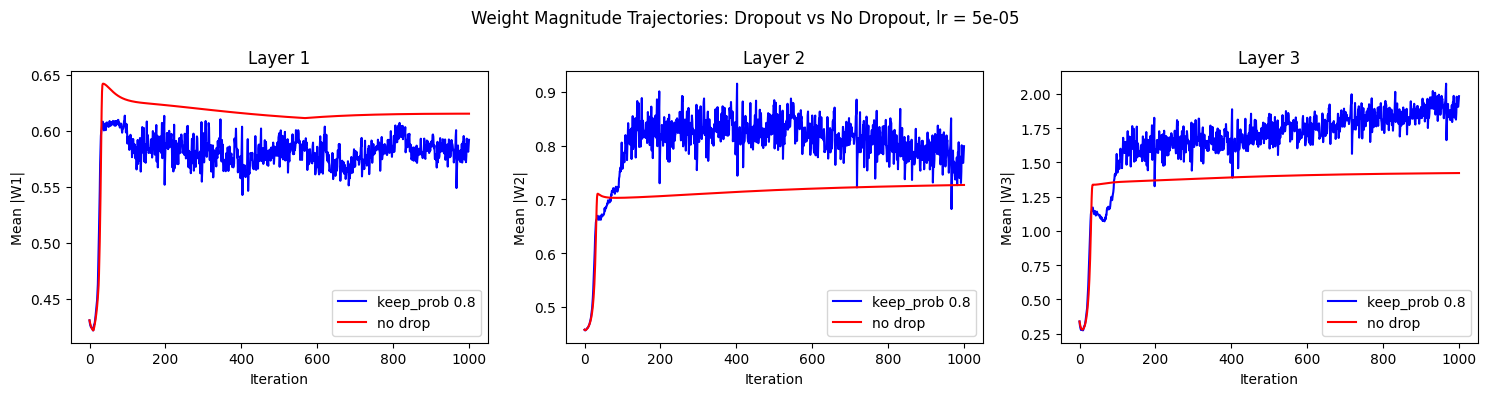

In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(
    f"Weight Magnitude Trajectories: Dropout vs No Dropout, lr = {learning_rate}"
)

for idx, l in enumerate(range(1, L + 1)):
    ax = axes[idx]
    # plot dropout run
    ax.plot(weight_log["drop"][f"W{l}"], c="b", label=f"keep_prob {keep_prob}")
    # plot no_dropout run
    ax.plot(weight_log["no_drop"][f"W{l}"], c="r", label="no drop")
    ax.set_title(f"Layer {l}")
    ax.set_xlabel("Iteration")
    ax.set_ylabel(f"Mean |W{l}|")
    ax.legend()

plt.tight_layout()
plt.show()

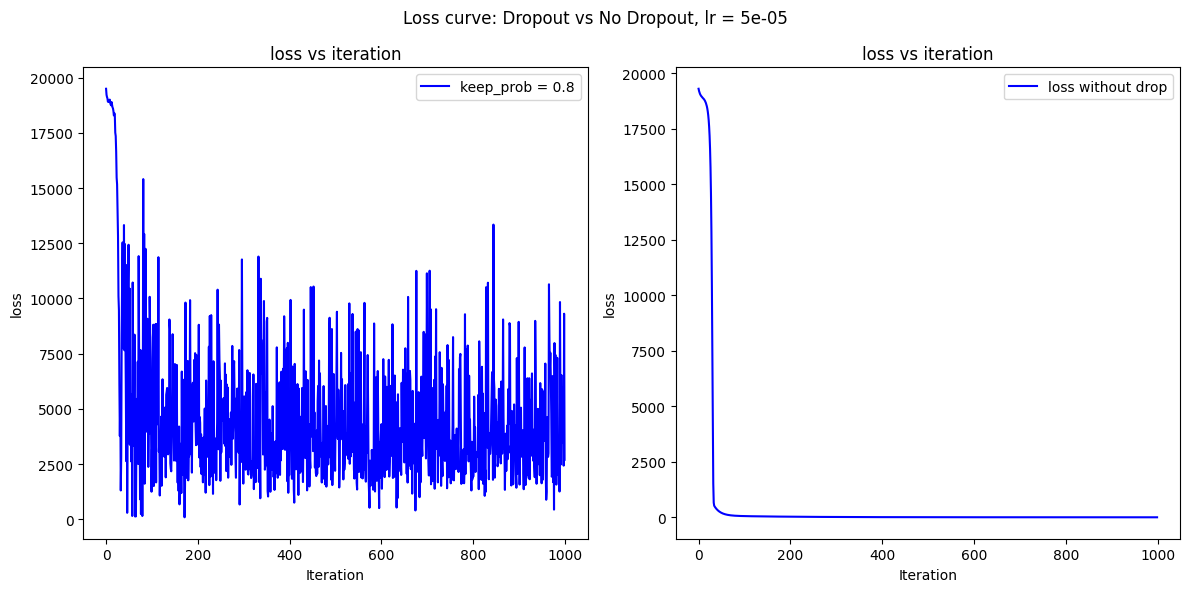

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle(f"Loss curve: Dropout vs No Dropout, lr = {learning_rate}")

ax[0].plot(loss_log["drop"], c="b", label=f"keep_prob = {keep_prob}")
ax[1].plot(loss_log["no_drop"], c="b", label="loss without drop")
for i in range(2):
    ax[i].set_title("loss vs iteration")
    ax[i].set_xlabel("Iteration")
    ax[i].set_ylabel("loss")
    ax[i].legend()

plt.tight_layout()
plt.show()

In [ ]:
# =========================
# 7. WEIGHT TRAJECTORY TRACKING
# =========================

In [ ]:
# keep_prob = 0.8
# m = y_train.shape[1]
# print(f"y_train = {y_train}")
# dZ3 = (cache["Z3"] - y_train) / m
# dW3 = dZ3 @ cache["A2"].T
# db3 = np.sum(dZ3, axis=1, keepdims=True)
# dA2 = params["W3"].T @ dZ3
# dA2_relu = (params["W3"].T @ dZ3) * (cache["masks"][2] / keep_prob)
# print(f"dZ3 = {dZ3}")
# print(f"dW3 = {dW3}")
# print(f"db3 = {db3}")
# print(f"dA2 = {dA2}")
# print(f"dA2_relu = {dA2_relu}")
# print(cache["masks"][2])

In [ ]:
# dZ2 = dA2_relu * (cache["Z2"] > 0)
# dW2 = dZ2 @ cache["A1"].T
# db2 = np.sum(dZ2, axis=1, keepdims=True)
# dA1 = params["W2"].T @ dZ2
# dA1_relu = (params["W2"].T @ dZ2) * (cache["masks"][1] / keep_prob)
# dZ1 = dA1_relu * (cache["Z1"] > 0)
# dW1 = dZ1 @ cache["A0"].T
# db1 = np.sum(dZ1, axis=1, keepdims=True)
# print(f"dZ2 = {dZ2}")
# print(f"dW2 = {dW2}")
# print(f"db2 = {db2}")
# print(f"dA1 = {dA1}")
# print(f"dA1_relu = {dA1_relu}")
# print(f"layer 1 mask : {cache["masks"][1]}")
# print(f"dZ1 = {dZ1}")
# print(f"dW1 = {dW1}")
# print(f"db1 = {db1}")